In [ ]:
!pip install agnpy

DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/astropy_healpix-1.1.3-py3.12-macosx-11.0-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/fermipy-1.4.1+5.g4046-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
INFO: pip is looking at multiple versions of astropy to determine which version is compatible with other requirements. This could take a while.


In [ ]:
from agnpy.spectra import ParticleDistribution
from agnpy.emission_regions.cone import *
import astropy.units as u
from agnpy.utils.conversion import nu_to_epsilon_prime, B_to_cgs, lambda_c_e, mec2
from agnpy.spectra.spectra import ExpCutoffPowerLaw
from agnpy.synchrotron import *
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid
from agnpy.synchrotron.base_synchrotron import Synchrotron
import numpy as np
from astropy.constants import c, sigma_T, m_e, e, mu0
#e = e.gauss
mec2 = mec2.to('eV')
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy.lib.array_utils'

# Changes in SED of Cone
We know SED of a Cone and Blob are similar when Cone is approximated as a Blob. But, when the following parameters of Cone changes, how does it affect the SED? 
- Power Changes
- Equipartition Parameter
- Radius
- Length of the Jet
- Opening angle of the Jet
- Electron escape 
- Doppler Factor
- Gamma_min? 
- Gamma_max?


1. Jet Power

We change the power of the jet and see how it affects the SED. 

In [ ]:
z=0.0686
B_o =  0.1 * u.G
R_o = 1 * 1e15 * u.cm
W_j = 7.63 * 1e36* u.W
L = (330 * u.pc)
theta_open = 9.7 * u.deg
Gamma = 12
theta_s = 2 * u.deg
A_equi = 1.0
# Electron Distribution imposed by Potter and Cotter
p = 2
gamma_minimum = 1*(5.11 * 1e6 * u.eV / mec2.to("eV")).value
gamma_c = (5.6 * 1e9 * u.eV / mec2.to("eV")).value
n_e = ExpCutoffPowerLaw(k = 1 , mass=m_e, p=p, gamma_min = gamma_minimum, gamma_max= 100*gamma_c, gamma_c= gamma_c )

In [ ]:
W_j_list = np.array([1e36, 5e36, 1e37, 5e37, 1e38, 5e38, 1e39]) * u.W
sed_nossa_W = []
for i, W_j in enumerate(W_j_list):
    jet_W = Cone.from_jet_power(W_j = W_j , B_0 = B_o, L = L, n_e = n_e, theta_open = theta_open, Gamma=Gamma,x_size=100,gamma_e_size=1000, z =z,electron_escape =True, escape_coefficient=3)
    syn_W= Synchrotron(jet_W)
    sed_nossa_W.append(syn_W.sed_flux(nu_obs,ssa=False))

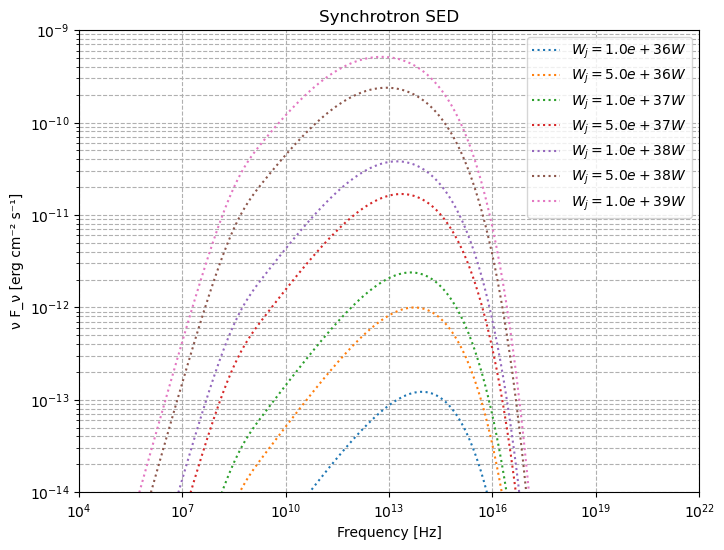

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

for i, sed in enumerate(sed_nossa_W):
    axes.loglog(
        nu_obs,
        sed,
        linestyle='dotted',
        label=f"$W_j={W_j_list[i]:.1e}$"
    )

axes.set_xlabel("Frequency [Hz]")
axes.set_ylabel("ν F_ν [erg cm⁻² s⁻¹]")
axes.set_title("Synchrotron SED")
axes.grid(True, which='both', ls='--')
axes.set_ylim(1e-14, 1e-9)
axes.set_xlim(1e4, 1e22)
axes.legend()

2. Equipartition Parameter

In [ ]:
A_list = np.array([1, 1e1, 5e1, 1e2, 5e2, 1e3, 5e3, 1e4]) 
sed_nossa_A = []
for A in A_list:
    jet_A = Cone.from_jet_power(W_j = W_j , B_0 = B_o, L= L, n_e = n_e, theta_open = theta_open, Gamma=Gamma,x_size=100,gamma_e_size=1000, z =z,electron_escape =True, escape_coefficient=3, A_equi = A)
    syn_A= Synchrotron(jet_A)
    sed_nossa_A.append(syn_A.sed_flux(nu_obs,ssa=False))

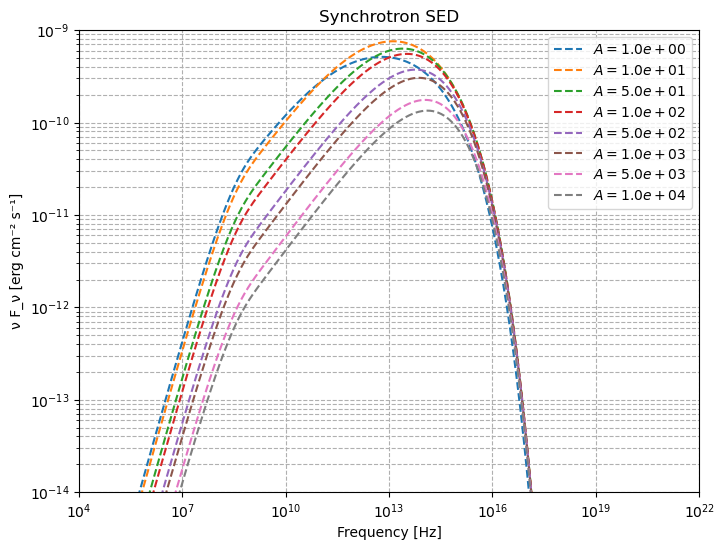

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

for i, sed in enumerate(sed_nossa_A):
    axes.loglog(
        nu_obs,
        sed,
        linestyle='--',
        label=f"$A={A_list[i]:.1e}$"
    )

axes.set_xlabel("Frequency [Hz]")
axes.set_ylabel("ν F_ν [erg cm⁻² s⁻¹]")
axes.set_title("Synchrotron SED")
axes.grid(True, which='both', ls='--')
axes.set_ylim(1e-14, 1e-9)
axes.set_xlim(1e4, 1e22)
axes.legend()

3. Radius

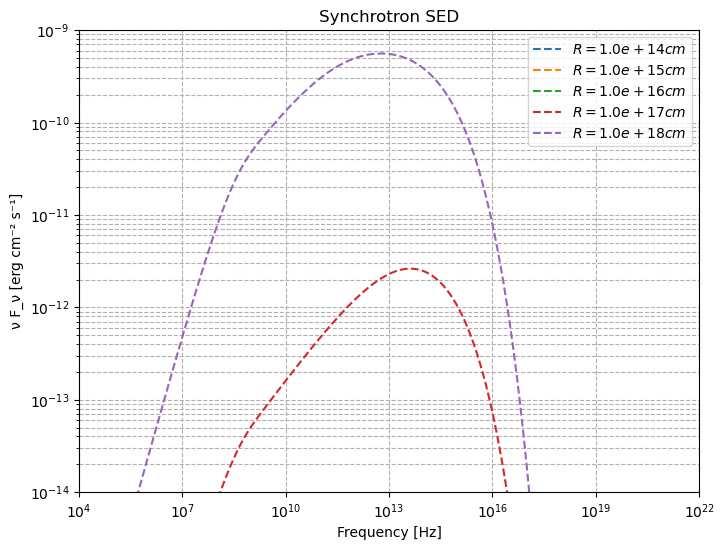

In [ ]:
R_list = np.array([1e14, 1e15, 1e16, 1e17, 1e18]) *u.cm
sed_nossa_R = []
for R in R_list:
    jet_R = Cone(R_0 = R , B_0 = B_o, L= L, n_e = n_e, theta_open = theta_open, Gamma=Gamma,x_size=100,gamma_e_size=1000, z =z,electron_escape =True, escape_coefficient=3, A_equi = 1)
    syn_R= Synchrotron(jet_R)
    sed_nossa_R.append(syn_R.sed_flux(nu_obs,ssa=False))

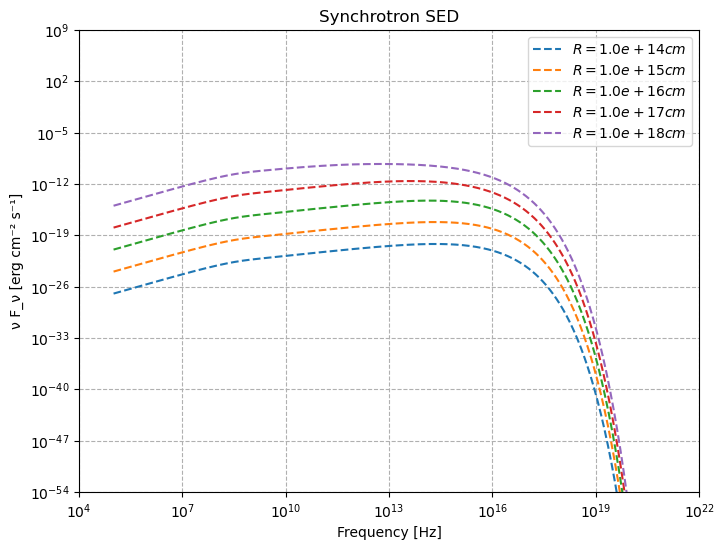

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

for i, sed in enumerate(sed_nossa_R):
    axes.loglog(
        nu_obs,
        sed,
        linestyle='--',
        label=f"$R={R_list[i]:.1e}$"
    )

axes.set_xlabel("Frequency [Hz]")
axes.set_ylabel("ν F_ν [erg cm⁻² s⁻¹]")
axes.set_title("Synchrotron SED")
axes.grid(True, which='both', ls='--')
axes.set_ylim(1e-54, 1e9)
axes.set_xlim(1e4, 1e22)
axes.legend()

Opening Angle -- Insignificant effect?

In [ ]:
theta_open_list = np.array([2, 4, 6, 8, 10, 15, 20,50, 80]) *u.deg
n_e_xg = [ ]
sed_theta = []
for theta in theta_open_list:
    jet_theta= Cone(R_0 = R , B_0 = B_o, L= L, n_e = n_e, theta_open = theta_open, Gamma=Gamma,x_size=100,gamma_e_size=1000, z =z,electron_escape =True, escape_coefficient=3, A_equi = 1)
    n_e_xg.append(jet_theta.N_e_xg)
    syn_theta= Synchrotron(jet_theta)
    sed_theta.append(syn_theta.sed_flux(nu_obs,ssa=False))

(10000000000.0, 1e+40)

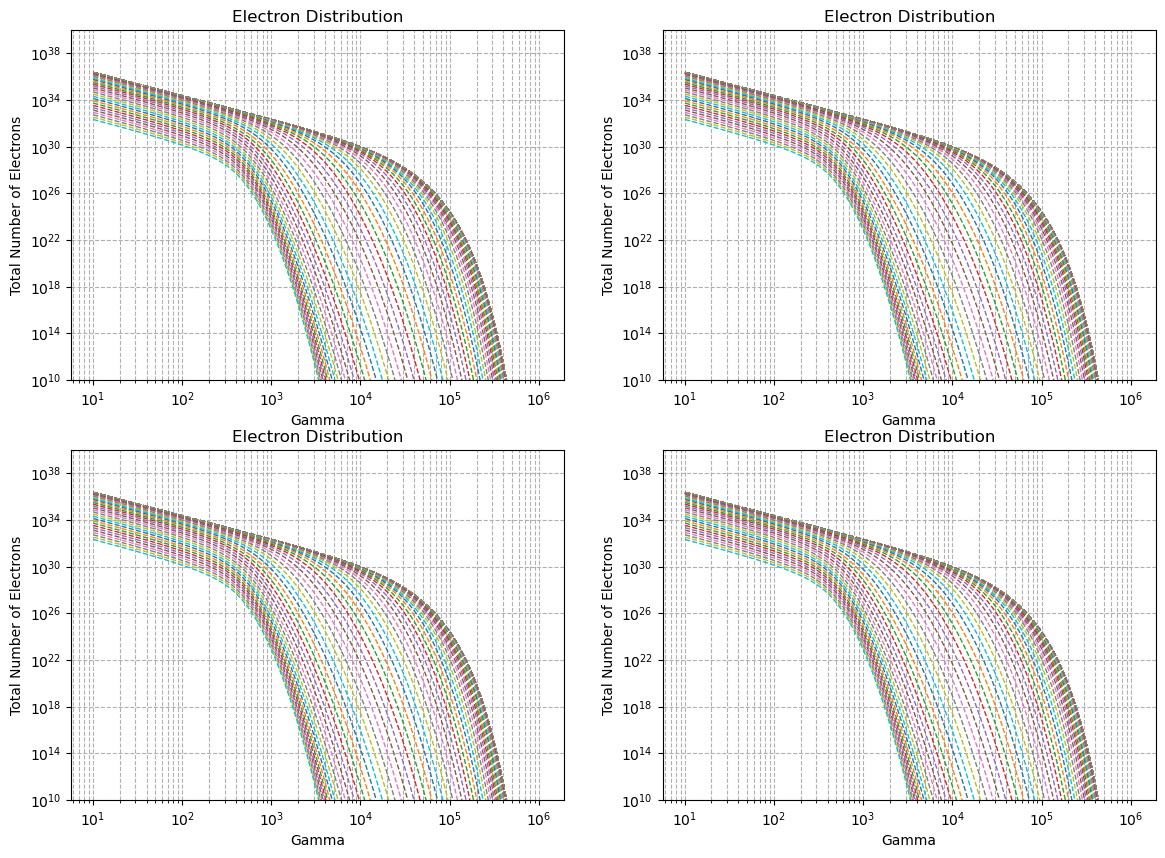

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, _n_e_g in enumerate(n_e_xg[1]):
    axes[0,0].loglog(jet.gamma_e, _n_e_g, label=f"x={jet_theta.x[i]}",linestyle='dashed',lw=1)
axes[0,0].set_xlabel("Gamma")
axes[0,0].set_ylabel("Total Number of Electrons")
axes[0,0].set_title("Electron Distribution")
axes[0,0].grid(True, which='both', ls='--')
axes[0,0].set_ylim(1e10, 1e40)
#axes[0,0].set_xlim(1e6, 1e12)
#axes[0,0].legend()

for i, _n_e_g in enumerate(n_e_xg[3]):
    axes[0,1].loglog(jet.gamma_e, _n_e_g, label=f"x={jet_theta.x[i]}",linestyle='dashed',lw=1)
axes[0,1].set_xlabel("Gamma")
axes[0,1].set_ylabel("Total Number of Electrons")
axes[0,1].set_title("Electron Distribution")
axes[0,1].grid(True, which='both', ls='--')
axes[0,1].set_ylim(1e10, 1e40)

for i, _n_e_g in enumerate(n_e_xg[6]):
    axes[1,0].loglog(jet.gamma_e, _n_e_g, label=f"x={jet_theta.x[i]}",linestyle='dashed',lw=1)
axes[1,0].set_xlabel("Gamma")
axes[1,0].set_ylabel("Total Number of Electrons")
axes[1,0].set_title("Electron Distribution")
axes[1,0].grid(True, which='both', ls='--')
axes[1,0].set_ylim(1e10, 1e40)

for i, _n_e_g in enumerate(n_e_xg[8]):
    axes[1,1].loglog(jet.gamma_e, _n_e_g, label=f"x={jet_theta.x[i]}",linestyle='dashed',lw=1)
axes[1,1].set_xlabel("Gamma")
axes[1,1].set_ylabel("Total Number of Electrons")
axes[1,1].set_title("Electron Distribution")
axes[1,1].grid(True, which='both', ls='--')
axes[1,1].set_ylim(1e10, 1e40)

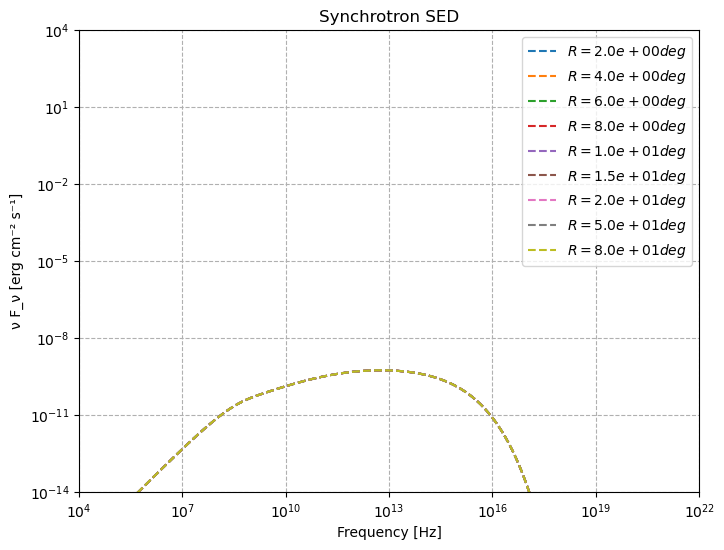

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

for i, sed in enumerate(sed_theta):
    axes.loglog(
        nu_obs,
        sed,
        linestyle='--',
        label=f"$R={theta_open_list[i]:.1e}$"
    )

axes.set_xlabel("Frequency [Hz]")
axes.set_ylabel("ν F_ν [erg cm⁻² s⁻¹]")
axes.set_title("Synchrotron SED")
axes.grid(True, which='both', ls='--')
axes.set_ylim(1e-14, 1e4)
axes.set_xlim(1e4, 1e22)
axes.legend()

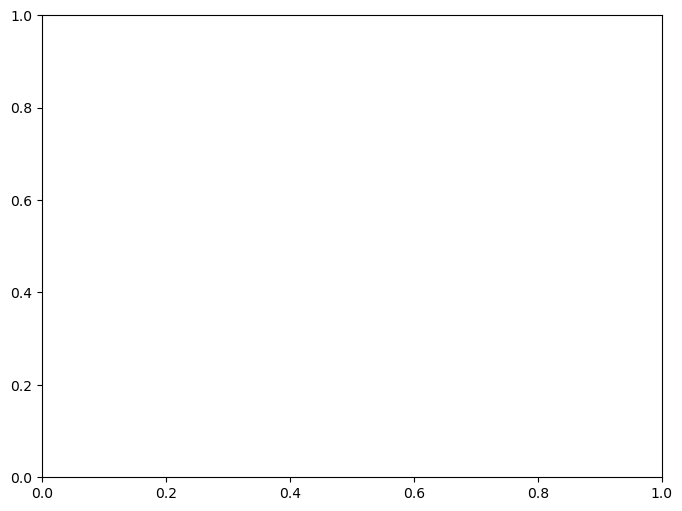

In [ ]:
escape_coeff_list = np.array([0.25, 1, 2, 3,6,10,20]) 
sed_escape = []
for escape in escape_coeff_list:
    jet_escape= Cone(R_0 = R_o , B_0 = B_o, L= L, n_e = n_e, theta_open = theta_open, Gamma=Gamma,x_size=100,gamma_e_size=1000, z =z,electron_escape =True, escape_coefficient= escape, A_equi = 1)
    syn_escape= Synchrotron(jet_escape)
    sed_escape.append(syn_escape.sed_flux(nu_obs,ssa=False))


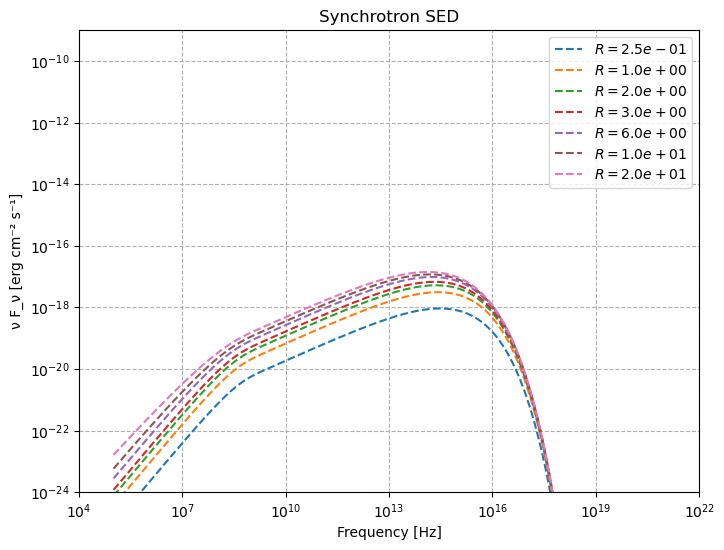

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
for i, sed in enumerate(sed_escape):
    axes.loglog(
        nu_obs,
        sed,
        linestyle='--',
        label=f"$R={escape_coeff_list[i]:.1e}$"
    )

axes.set_xlabel("Frequency [Hz]")
axes.set_ylabel("ν F_ν [erg cm⁻² s⁻¹]")
axes.set_title("Synchrotron SED")
axes.grid(True, which='both', ls='--')
axes.set_ylim(1e-24 ,1e-9)
axes.set_xlim(1e4, 1e22)
axes.legend()

Doppler Factor

In [ ]:
doppler_list = np.array([1, 3, 5, 10, 20, 50, 100]) 
sed_doppler = []
for doppler in doppler_list:
    jet_doppler= Cone(R_0 = R_o , B_0 = B_o, L= L, n_e = n_e, theta_open = theta_open, delta_D = doppler,x_size=100,gamma_e_size=1000, z =z,electron_escape =True, escape_coefficient= escape, A_equi = 1)
    syn_doppler= Synchrotron(jet_doppler)
    sed_doppler.append(syn_doppler.sed_flux(nu_obs,ssa=False))

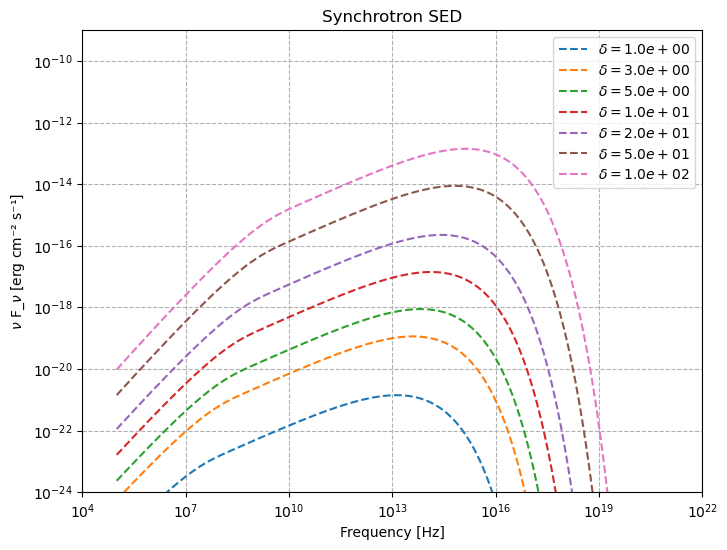

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
for i, sed in enumerate(sed_doppler):
    axes.loglog(
        nu_obs,
        sed,
        linestyle='--',
        label=f"$δ={doppler_list[i]:.1e}$"
    )

axes.set_xlabel("Frequency [Hz]")
axes.set_ylabel("$ν$ F_$ν$ [erg cm⁻² s⁻¹]")
axes.set_title("Synchrotron SED")
axes.grid(True, which='both', ls='--')
axes.set_ylim(1e-24 ,1e-9)
axes.set_xlim(1e4, 1e22)
axes.legend()